# Instruments d’optique et application à la focométrie

**Correction de référence — durée indicative : 2 h**

Noms : Exemple de correction  
Date de la séance : 

Ce notebook doit permettre à une personne qui n’a pas assisté au TP de comprendre les méthodes employées, les mesures réalisées, leur exploitation et les conclusions obtenues.


**Énoncé du TP :** [Instruments d’optique et application à la focométrie](https://pcsi.daniel-mengel.net/Instruments-doptique-et-application-a-la-focometrie.pdf)

## Objectifs du TP

- Connaître plusieurs méthodes de focométrie et savoir les appliquer.
- Régler et utiliser une lunette de visée et un collimateur.
- Si le temps le permet, utiliser un viseur à frontale fixe.
- Déterminer des distances focales avec leur incertitude et comparer les résultats obtenus.

Il n’est pas demandé de reformuler ces objectifs généraux. Pour chaque nouvelle manipulation, vous préciserez en revanche son objectif propre avant de décrire le protocole.


In [1]:
import numpy as np

N = 10_000

def ecart_normalise(x, ux, x_ref, ux_ref=0):
    return abs(x - x_ref) / np.sqrt(ux**2 + ux_ref**2)


## 1. Autocollimation — lentille convergente +5

Placez sur le banc l’objet lumineux (voir énoncé du TP), la lentille convergente $+5$ et un miroir plan juste derrière la lentille, sur le même support.

Lorsque l’objet est dans le plan focal objet de la lentille, l’image renvoyée par le miroir se forme dans le plan de l’objet et possède la même taille. La distance objet–lentille est alors égale à la distance focale image $f'_1$.

![Auto collimation.png](<attachment:Auto collimation.png>)

Vous devrez déterminer $f'_1$, estimer son incertitude et vérifier la cohérence avec la valeur indiquée par le constructeur.

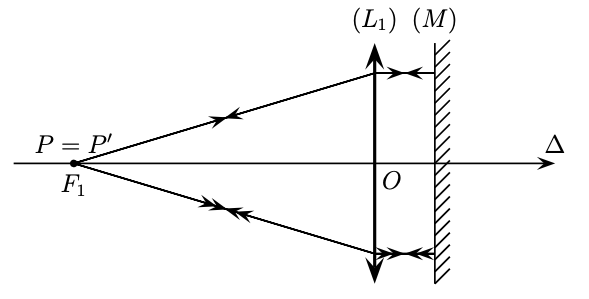

<!-- autocollimation-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Objectif et protocole de l’autocollimation

Indiquez l’objectif de cette manipulation (en relisant l’énoncé du TP si nécessaire). Décrivez ensuite comment vous recherchez la superposition de l’objet et de son image, les positions relevées, le critère de netteté retenu et la manière dont vous estimez les demi-largeurs $\Delta d$ des intervalles de position.

### Réponse :

L’objectif est de déterminer la distance focale image de la lentille convergente +5. Nous plaçons le miroir juste derrière la lentille et déplaçons l’ensemble lentille–miroir jusqu’à ce que l’image renversée de la lettre soit nette, de même taille et superposée à l’objet. Nous relevons la position de l’objet et celle de la lentille. Les demi-largeurs retenues correspondent aux intervalles dans lesquels la superposition et la netteté restent acceptables.

</div>

In [2]:
# Mesures du binôme, en cm
# d0m : position de l’objet ; d1m : position de l’ensemble lentille + miroir
d0m = 5.0
Delta_d0 = 0.3
d1m = 25.4
Delta_d1 = 0.6

assert None not in [d0m, Delta_d0, d1m, Delta_d1], "Compléter les mesures et leurs demi-largeurs."

# Incertitudes de type B : positions supposées uniformément réparties dans les intervalles retenus
d0 = np.random.uniform(d0m - Delta_d0, d0m + Delta_d0, N)
d1 = np.random.uniform(d1m - Delta_d1, d1m + Delta_d1, N)
f1_values = abs(d1 - d0)

f1 = f1_values.mean()
u_f1 = f1_values.std()
f1_constructeur = 100 / 5
E_n_f1 = ecart_normalise(f1, u_f1, f1_constructeur)

print("f'1 =", round(f1, 1), "+/-", round(u_f1, 1), "cm")
print("Valeur constructeur =", round(f1_constructeur, 1), "cm")
print("Écart normalisé =", round(E_n_f1, 2))


f'1 = 20.4 +/- 0.4 cm
Valeur constructeur = 20.0 cm
Écart normalisé = 1.03


<!-- autocollimation-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Résultat de l’autocollimation

Écrivez explicitement le résultat sous la forme $f'_1=\ldots\pm\ldots\,\mathrm{cm}$, avec un arrondi conforme au TP-cours sur les incertitudes. Interprétez l’écart normalisé et discutez les principales limites expérimentales.

### Réponse :

La simulation donne $f'_1=(20{,}4\pm0{,}4)\,\mathrm{cm}$. L’écart normalisé est inférieur à 2 : le résultat est compatible avec les 20 cm attendus pour une lentille +5. La principale limite vient du caractère subjectif de la superposition et de la netteté de l’image.

</div>

## 2. Lentille divergente −2 — méthode de la boîte de verre

L’autocollimation ne peut pas être appliquée directement à une lentille divergente. Accolez-la à la lentille convergente $+5$ afin d’obtenir un système convergent.

Pour deux lentilles minces accolées :

$$V_{\mathrm{ensemble}}=V_{+5}+V_{-2}$$

La mesure par autocollimation de la distance focale de l’ensemble permet donc de déterminer la vergence, puis la distance focale $f'_2$ de la lentille divergente.


<!-- diverging-box-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Objectif et protocole de la boîte de verre

Indiquez l’objectif de cette manipulation (en relisant l’énoncé du TP si nécessaire). Décrivez la constitution de l’association de lentilles, la recherche de l’autocollimation et les grandeurs mesurées. Précisez comment vous évitez de confondre la focale de l’ensemble avec celle de la lentille divergente seule.

### Réponse :

L’objectif est de déterminer la distance focale de la lentille divergente −2. Nous l’accolons à la lentille convergente +5 afin d’obtenir un ensemble convergent, puis nous mesurons par autocollimation la distance focale de cet ensemble. Nous calculons ensuite sa vergence et retranchons 5 dioptries pour isoler la vergence de la lentille divergente.

</div>

In [3]:
# Mesure par autocollimation de l’association +5 / -2, en cm
d0m_box = 5.0
Delta_d0_box = 0.3
d1m_box = 39.1
Delta_d1_box = 0.8

assert None not in [d0m_box, Delta_d0_box, d1m_box, Delta_d1_box],     "Compléter les mesures de la boîte de verre."

d0_box = np.random.uniform(d0m_box - Delta_d0_box, d0m_box + Delta_d0_box, N)
d1_box = np.random.uniform(d1m_box - Delta_d1_box, d1m_box + Delta_d1_box, N)

f_box_m = abs(d1_box - d0_box) / 100
V_box = 1 / f_box_m
V_convergente = 5
V_divergente = V_box - V_convergente
f2_values = 100 / V_divergente

f2 = f2_values.mean()
u_f2 = f2_values.std()
f2_constructeur = 100 / (-2)
E_n_f2 = ecart_normalise(f2, u_f2, f2_constructeur)

print("f'2 =", round(f2, 1), "+/-", round(u_f2, 1), "cm")
print("Valeur constructeur =", round(f2_constructeur, 1), "cm")
print("Écart normalisé =", round(E_n_f2, 2))


f'2 = -48.4 +/- 1.0 cm
Valeur constructeur = -50.0 cm
Écart normalisé = 1.6


<!-- diverging-box-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Résultat pour la lentille divergente

Écrivez explicitement le résultat sous la forme $f'_2=\ldots\pm\ldots\,\mathrm{cm}$. Vérifiez que son signe est cohérent avec la nature de la lentille, interprétez l’écart normalisé et commentez les limites de cette méthode indirecte.

### Réponse :

On obtient $f'_2=(-48\pm1)\,\mathrm{cm}$. Le signe négatif est cohérent avec une lentille divergente. L’écart normalisé avec les −50 cm attendus est inférieur à 2. Cette méthode est indirecte : l’incertitude sur la focale de l’ensemble et l’hypothèse de lentilles minces parfaitement accolées limitent la précision.

</div>

## 3. Méthode de Bessel — lentille convergente +3,3

Pour une distance objet–écran $D$ supérieure à $4f'$, il existe deux positions de la lentille donnant une image nette. Si $d$ est la distance entre ces deux positions :


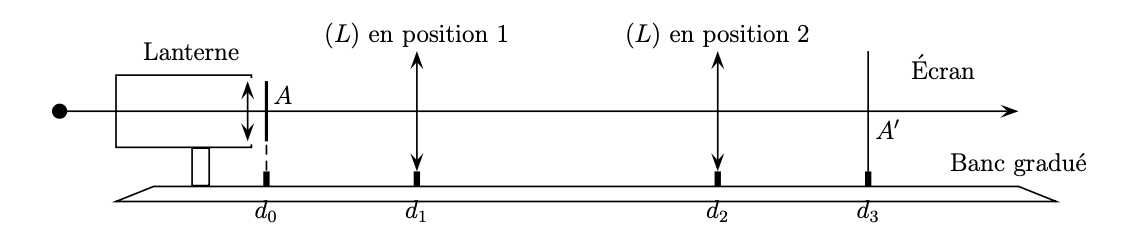

$$f'=\frac{D^2-d^2}{4D}$$

avec $D=d_3-d_0$ et $d=d_2-d_1$.


<!-- bessel-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Objectif et protocole de la méthode de Bessel

Indiquez l’objectif de cette manipulation (en relisant l’énoncé du TP si nécessaire). Décrivez comment vous fixez l’objet et l’écran, recherchez les deux positions de netteté de la lentille $+3,3$, relevez $d_0$, $d_1$, $d_2$ et $d_3$, puis estimez leurs intervalles d’incertitude.

### Réponse :

L’objectif est de déterminer la distance focale de la lentille +3,3 par la méthode de Bessel. Nous fixons l’objet et l’écran à une distance supérieure à quatre fois la focale attendue. Nous recherchons les deux positions de la lentille donnant une image nette, puis relevons les positions de l’objet, des deux positions de la lentille et de l’écran. Les intervalles traduisent la plage de positions pour laquelle l’image paraît encore nette.

</div>

In [4]:
# Positions sur le banc, en cm
# d0 : objet ; d1 et d2 : deux positions de la lentille ; d3 : écran
d0m_bessel = 5.0
Delta_d0_bessel = 0.3
d1m_bessel = 44.0
Delta_d1_bessel = 0.5
d2m_bessel = 141.0
Delta_d2_bessel = 0.5
d3m_bessel = 180.0
Delta_d3_bessel = 0.2

assert None not in [d0m_bessel, Delta_d0_bessel, d1m_bessel, Delta_d1_bessel,
                    d2m_bessel, Delta_d2_bessel, d3m_bessel, Delta_d3_bessel],     "Compléter les mesures de Bessel."

d0_bessel = np.random.uniform(d0m_bessel - Delta_d0_bessel, d0m_bessel + Delta_d0_bessel, N)
d1_bessel = np.random.uniform(d1m_bessel - Delta_d1_bessel, d1m_bessel + Delta_d1_bessel, N)
d2_bessel = np.random.uniform(d2m_bessel - Delta_d2_bessel, d2m_bessel + Delta_d2_bessel, N)
d3_bessel = np.random.uniform(d3m_bessel - Delta_d3_bessel, d3m_bessel + Delta_d3_bessel, N)

D = abs(d3_bessel - d0_bessel)
d = abs(d2_bessel - d1_bessel)
assert D.mean() > 4 * (100 / 3.3), "La condition moyenne D > 4 f' n’est pas satisfaite."

f3_bessel_values = (D**2 - d**2) / (4 * D)
f3_bessel = f3_bessel_values.mean()
u_f3_bessel = f3_bessel_values.std()
f3_constructeur = 100 / 3.3
E_n_bessel = ecart_normalise(f3_bessel, u_f3_bessel, f3_constructeur)

print("D =", round(D.mean(), 1), "cm")
print("d =", round(d.mean(), 1), "cm")
print("f'3 par Bessel =", round(f3_bessel, 1), "+/-", round(u_f3_bessel, 1), "cm")
print("Écart normalisé avec la valeur constructeur =", round(E_n_bessel, 2))


D = 175.0 cm
d = 97.0 cm
f'3 par Bessel = 30.3 +/- 0.1 cm
Écart normalisé avec la valeur constructeur = 0.04


<!-- bessel-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Résultat de la méthode de Bessel

Écrivez explicitement le résultat de Bessel sous la forme $f'_3=\ldots\pm\ldots\,\mathrm{cm}$. Vérifiez la condition $D>4f'$, interprétez la comparaison avec la valeur constructeur et identifiez les mesures qui limitent principalement la précision.

### Réponse :

La distance objet–écran est bien supérieure à quatre fois la focale attendue. La méthode de Bessel donne $f'_3=(30{,}3\pm0{,}1)\,\mathrm{cm}$. L’écart normalisé avec la valeur constructeur est inférieur à 2. La précision est principalement limitée par le repérage des deux positions de meilleure netteté.

</div>

## 4. Lunette, collimateur et application à la focométrie

### Réglage de la lunette

1. Enfoncez d’abord l’oculaire au maximum.
2. En visant une surface claire, éloignez progressivement l’oculaire du réticule jusqu’à obtenir une image nette du réticule. Ce réglage dépend de la vue de l’observateur.
3. Sans modifier ce premier réglage, visez un objet très éloigné et déplacez l’ensemble réticule–oculaire afin d’observer simultanément l’objet et le réticule nets.

La lunette est alors réglée à l’infini. Ne la déréglez plus.

### Réglage du collimateur

Le collimateur doit former à l’infini l’image de son objet test. Observez son test à travers la lunette réglée à l’infini et modifiez le tirage du collimateur jusqu’à voir simultanément le test et le réticule nets, sans déplacement relatif lorsque vous bougez légèrement la tête.

**Sécurité :** placez un calque entre la source et le collimateur pour atténuer la luminosité.

Ces réglages sont guidés pendant la séance et n’ont pas à être détaillés dans le rapport.

### Mesure de la lentille +3,3

Placez ensuite la lentille convergente dans le faisceau parallèle issu du collimateur. Son image se forme dans le plan focal image ; ainsi :


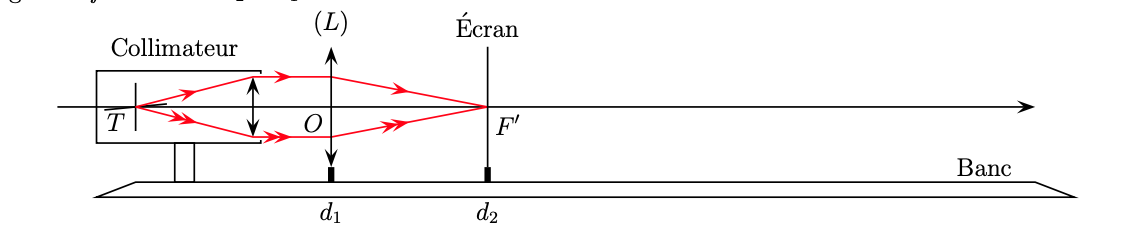


$$f'=d_2-d_1$$


<!-- collimator-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Objectif et protocole de la mesure au collimateur

Indiquez l’objectif de cette manipulation (en relisant l’énoncé du TP si nécessaire). Décrivez uniquement le positionnement de la lentille et de l’écran, le critère de netteté et les positions mesurées ; il est inutile de recopier les étapes de réglage guidées ci-dessus.

### Réponse :

L’objectif est de mesurer à nouveau la focale de la lentille +3,3 à partir d’un faisceau parallèle. Après le réglage guidé du collimateur, nous plaçons la lentille dans le faisceau, déplaçons l’écran jusqu’à obtenir une image nette, puis relevons les positions de la lentille et de l’écran.

</div>

In [5]:
# Positions sur le banc, en cm
d1m_collimateur = 25.0
Delta_d1_collimateur = 0.4
d2m_collimateur = 55.4
Delta_d2_collimateur = 0.3

assert None not in [d1m_collimateur, Delta_d1_collimateur,
                    d2m_collimateur, Delta_d2_collimateur],     "Compléter les mesures au collimateur."

d1_collimateur = np.random.uniform(d1m_collimateur - Delta_d1_collimateur,
                                   d1m_collimateur + Delta_d1_collimateur, N)
d2_collimateur = np.random.uniform(d2m_collimateur - Delta_d2_collimateur,
                                   d2m_collimateur + Delta_d2_collimateur, N)

f3_collimateur_values = abs(d2_collimateur - d1_collimateur)
f3_collimateur = f3_collimateur_values.mean()
u_f3_collimateur = f3_collimateur_values.std()
E_n_collimateur_constructeur = ecart_normalise(f3_collimateur, u_f3_collimateur, f3_constructeur)
E_n_bessel_collimateur = ecart_normalise(f3_collimateur, u_f3_collimateur,
                                         f3_bessel, u_f3_bessel)

print("f'3 au collimateur =", round(f3_collimateur, 1), "+/-", round(u_f3_collimateur, 1), "cm")
print("Écart normalisé avec la valeur constructeur =", round(E_n_collimateur_constructeur, 2))
print("Écart normalisé entre Bessel et collimateur =", round(E_n_bessel_collimateur, 2))


f'3 au collimateur = 30.4 +/- 0.3 cm
Écart normalisé avec la valeur constructeur = 0.34
Écart normalisé entre Bessel et collimateur = 0.29


<!-- collimator-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Comparaison Bessel–collimateur

Écrivez explicitement le résultat obtenu au collimateur sous la forme $f'_3=\ldots\pm\ldots\,\mathrm{cm}$. Comparez-le à la valeur constructeur et au résultat de Bessel en interprétant les écarts normalisés. Indiquez si le réglage du collimateur paraît limiter la mesure.

### Réponse :

La méthode du collimateur donne $f'_3=(30{,}4\pm0{,}3)\,\mathrm{cm}$. Cette valeur est compatible avec la valeur constructeur et avec celle obtenue par Bessel : les deux écarts normalisés sont inférieurs à 2. Le réglage du collimateur et l’appréciation de la netteté peuvent toutefois introduire un décalage systématique.

</div>

## 5. Viseur à frontale fixe — prolongement facultatif

Cette partie n’est réalisée que si le temps restant le permet.

Réglez le viseur afin d’observer nettement un objet situé à quelques dizaines de centimètres. Avec le collimateur et la même lentille divergente $-2$ que précédemment, relevez successivement la position $P_1$ du viseur lorsqu’il vise une marque portée sur la lentille, puis la position $P_2$ lorsqu’il vise l’image virtuelle du test.

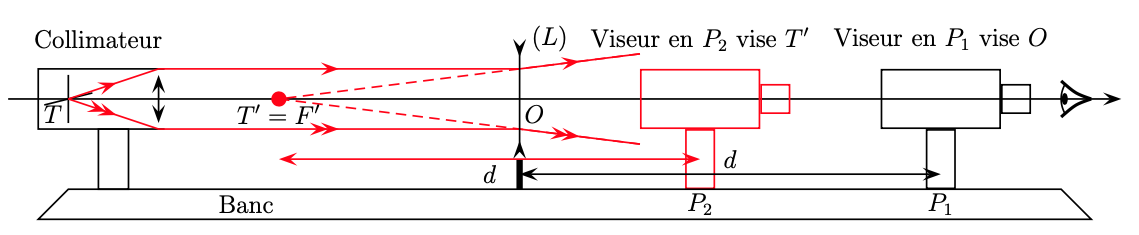


Avec l’orientation du banc indiquée dans l’énoncé :

$$f'_2\,(\text{viseur})=\overline{P_1P_2}=P_2-P_1<0$$


<!-- vff-protocol-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Objectif et protocole au viseur — facultatif

Si vous réalisez cette partie, indiquez l’objectif de cette manipulation (en relisant l’énoncé du TP si nécessaire) et décrivez les deux visées nécessaires. Sinon, écrivez simplement « Manipulation non réalisée faute de temps ».

### Réponse :

L’objectif est de mesurer à nouveau la distance focale $f'_2$ de la lentille divergente −2, cette fois au viseur, pour la comparer à la mesure par boîte de verre. Nous visons d’abord la marque tracée sur la lentille et relevons la position $P_1$, puis nous déplaçons le viseur pour observer nettement l’image virtuelle du test et relevons $P_2$. Le déplacement orienté $P_2-P_1$ donne la distance focale.

</div>

In [6]:
# Partie facultative : laisser les valeurs à None si elle n’a pas été réalisée.
P1m = 90.5
Delta_P1 = 0.6
P2m = 40.5
Delta_P2 = 0.8

if None not in [P1m, Delta_P1, P2m, Delta_P2]:
    P1 = np.random.uniform(P1m - Delta_P1, P1m + Delta_P1, N)
    P2 = np.random.uniform(P2m - Delta_P2, P2m + Delta_P2, N)
    f2_viseur_values = P2 - P1
    f2_viseur = f2_viseur_values.mean()
    u_f2_viseur = f2_viseur_values.std()
    E_n_viseur_constructeur = ecart_normalise(f2_viseur, u_f2_viseur, f2_constructeur)
    E_n_viseur_boite = ecart_normalise(f2_viseur, u_f2_viseur, f2, u_f2)

    print("f'2 au viseur =", round(f2_viseur, 1), "+/-", round(u_f2_viseur, 1), "cm")
    print("Écart normalisé avec la valeur constructeur =", round(E_n_viseur_constructeur, 2))
    print("Écart normalisé entre boîte de verre et viseur =", round(E_n_viseur_boite, 2))
else:
    print("Manipulation facultative non réalisée.")


f'2 au viseur = -50.0 +/- 0.6 cm
Écart normalisé avec la valeur constructeur = 0.01
Écart normalisé entre boîte de verre et viseur = 1.37


<!-- vff-result-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Résultat au viseur — facultatif

Si la manipulation a été réalisée, écrivez explicitement le résultat sous la forme $f'_2\,(\text{viseur})=\ldots\pm\ldots\,\mathrm{cm}$, vérifiez son signe, puis calculez et interprétez les écarts normalisés avec la valeur constructeur et avec la mesure de $f'_2$ obtenue par la boîte de verre (seuil 2). Sinon, écrivez « Manipulation non réalisée faute de temps ».

### Réponse :

Le viseur donne $f'_2\,(\text{viseur})=(-50{,}0\pm0{,}6)\,\mathrm{cm}$. Le signe négatif est conforme au caractère divergent de la lentille. L’écart normalisé avec les −50 cm correspondant à −2 dioptries est voisin de 0,01 ; celui avec la valeur calculée par la boîte de verre, $f'_2=(-48{,}4\pm1{,}0)\,\mathrm{cm}$ avant l’arrondi de présentation, est voisin de 1,37. Les deux valeurs étant inférieures à 2, ces mesures sont compatibles. La visée de l’image virtuelle est moins précise que celle de la marque portée sur la lentille.

</div>

<!-- focometry-final-conclusion-response -->
<div style="background-color:#F5F8FC; border:1px solid #DCE6F0; padding:12px 16px; border-radius:4px; color:#202124;">

### Conclusion générale

Présentez les distances focales obtenues avec leurs incertitudes, les comparaisons pertinentes et les principales limites expérimentales. Concluez sur l’intérêt et les domaines d’emploi des différentes méthodes de focométrie. La conclusion doit rester compréhensible sans exécuter le notebook.

### Réponse :

L’autocollimation permet une mesure directe et rapide de la lentille convergente +5. L’association de lentilles étend cette méthode à la lentille divergente −2, au prix d’un calcul indirect. Pour la lentille +3,3, les méthodes de Bessel et du collimateur conduisent à des valeurs compatibles entre elles et avec le constructeur. La méthode de Bessel ne nécessite pas de réglage préalable d’un instrument, tandis que le collimateur fournit une mesure rapide une fois correctement réglé. Le viseur à frontale fixe permet enfin de mesurer directement le déplacement associé à l’image virtuelle d’une lentille divergente. Les principales limites proviennent du critère de netteté, de la lecture des positions et des réglages optiques.

</div>

## Liste d’auto-vérification avant rendu

- [ ] Les noms et la date sont indiqués.
- [ ] Chaque manipulation réalisée comporte un objectif propre et un protocole compréhensible.
- [ ] Toutes les données sont celles du binôme et portent une unité.
- [ ] Les demi-largeurs des intervalles de mesure sont justifiées.
- [ ] Les résultats sont donnés avec une incertitude et un arrondi cohérent.
- [ ] Les écarts normalisés sont interprétés, et pas seulement calculés.
- [ ] Les méthodes de Bessel et du collimateur sont comparées.
- [ ] La partie facultative est renseignée comme réalisée ou non réalisée.
- [ ] La conclusion répond aux objectifs généraux du TP.


<!-- notebook-submission-reminder -->
<div style="margin-top:24px; padding:18px 20px; border:1px solid #DCE6F0; border-radius:6px; background-color:#F5F8FC; text-align:center;">

<strong>Notebook terminé ?</strong> Enregistrez la version complétée au format <code>.ipynb</code>, puis déposez-la sur la Dropbox prévue pour le rendu.

<p style="margin:18px 0 4px 0;">
  <a href="https://www.dropbox.com/request/1F5bFZrnz5KKllqtkPsE" target="_blank" rel="noopener noreferrer" style="display:inline-block; padding:10px 18px; border-radius:5px; background-color:#4F9CC7; color:white; text-decoration:none; font-weight:600;">Déposer le notebook complété</a>
</p>

</div>